<div align="center">

#  Netflix Content Analysis — End-to-End EDA
### A Professional Data Analyst Portfolio Project

---

**Dataset:** Netflix Titles (8,807 entries · 12 features)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Author:** Muskan Kumari | [LinkedIn](https://www.linkedin.com/in/muskan-kumari-b8ba012ba/) | [GitHub](https://github.com/Muskan-collab)

---

</div>

## 📋 Project Overview

Netflix is the world's leading streaming platform with **200M+ subscribers globally**.  
This notebook performs a complete **Exploratory Data Analysis (EDA)** on Netflix's content library to uncover patterns in content distribution, ratings, genres, countries, and release trends.

### 🎯 Business Questions We'll Answer:
1. What is the ratio of Movies vs TV Shows on Netflix?
2. Which countries produce the most Netflix content?
3. What are the most common content ratings?
4. Which genres dominate the platform?
5. How has Netflix's content library grown over the years?
6. Who are the most prolific directors on Netflix?
7. What is the typical movie duration & TV show season count?

---


---
##  Section 1: Import Libraries

We start by importing all the essential Python libraries needed for data manipulation and visualization.


In [1]:
# ── Core Data Libraries ──────────────────────────────────────────
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations

# ── Visualization Libraries ──────────────────────────────────────
import matplotlib.pyplot as plt      # Base plotting
import matplotlib.ticker as mticker
import seaborn as sns                # Statistical visualizations

# ── Display & Formatting ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # Suppress non-critical warnings

# ── Global Plot Style ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style("whitegrid")
PALETTE = ["#E50914", "#221F1F", "#F5F5F1", "#B81D24", "#E87C03",
           "#564D4D", "#831010", "#FF6B6B", "#C62828", "#4A4A4A"]

print("✅ All libraries imported successfully!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Seaborn : {sns.__version__}")


✅ All libraries imported successfully!
   Pandas  : 3.0.2
   NumPy   : 2.4.4
   Seaborn : 0.13.2


---
## 📂 Section 2: Load the Dataset

We load the Netflix titles CSV file and take a first look at its structure.


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────
df = pd.read_csv('netflix_titles.csv')

# Display the first 5 rows
print("🎬 First 5 rows of the Netflix Dataset:")
df.head()


🎬 First 5 rows of the Netflix Dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Display the last 5 rows
print("🎬 Last 5 rows of the Netflix Dataset:")
df.tail()


🎬 Last 5 rows of the Netflix Dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


---
## 🔍 Section 3: Dataset Overview

Let's understand the shape, column names, data types, and basic statistics of our dataset.


In [4]:
# ── Shape of the Dataset ────────────────────────────────────────
rows, cols = df.shape
print(f"📊 Dataset Shape: {rows} rows × {cols} columns")
print(f"   → {rows:,} Netflix titles with {cols} attributes each\n")

# ── Column Names ─────────────────────────────────────────────────
print("📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:02d}. {col}")


📊 Dataset Shape: 8807 rows × 12 columns
   → 8,807 Netflix titles with 12 attributes each

📋 Column Names:
   01. show_id
   02. type
   03. title
   04. director
   05. cast
   06. country
   07. date_added
   08. release_year
   09. rating
   10. duration
   11. listed_in
   12. description


In [5]:
# ── Data Types & Non-Null Counts ─────────────────────────────────
print("📝 Dataset Info:")
df.info()


📝 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
# ── Statistical Summary ──────────────────────────────────────────
print("📈 Statistical Summary (Numerical Columns):")
df.describe()


📈 Statistical Summary (Numerical Columns):


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# ── Categorical Summary ──────────────────────────────────────────
print("📊 Categorical Column Summary:")
df.describe(include='object')


📊 Categorical Column Summary:


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


---
## 🔎 Section 4: Missing Value Analysis

Missing values can skew our analysis. Let's identify, visualize, and handle them carefully.


In [8]:
# ── Count Missing Values ────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("❗ Missing Value Report:")
print(missing_df[missing_df['Missing Count'] > 0].to_string())


❗ Missing Value Report:
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


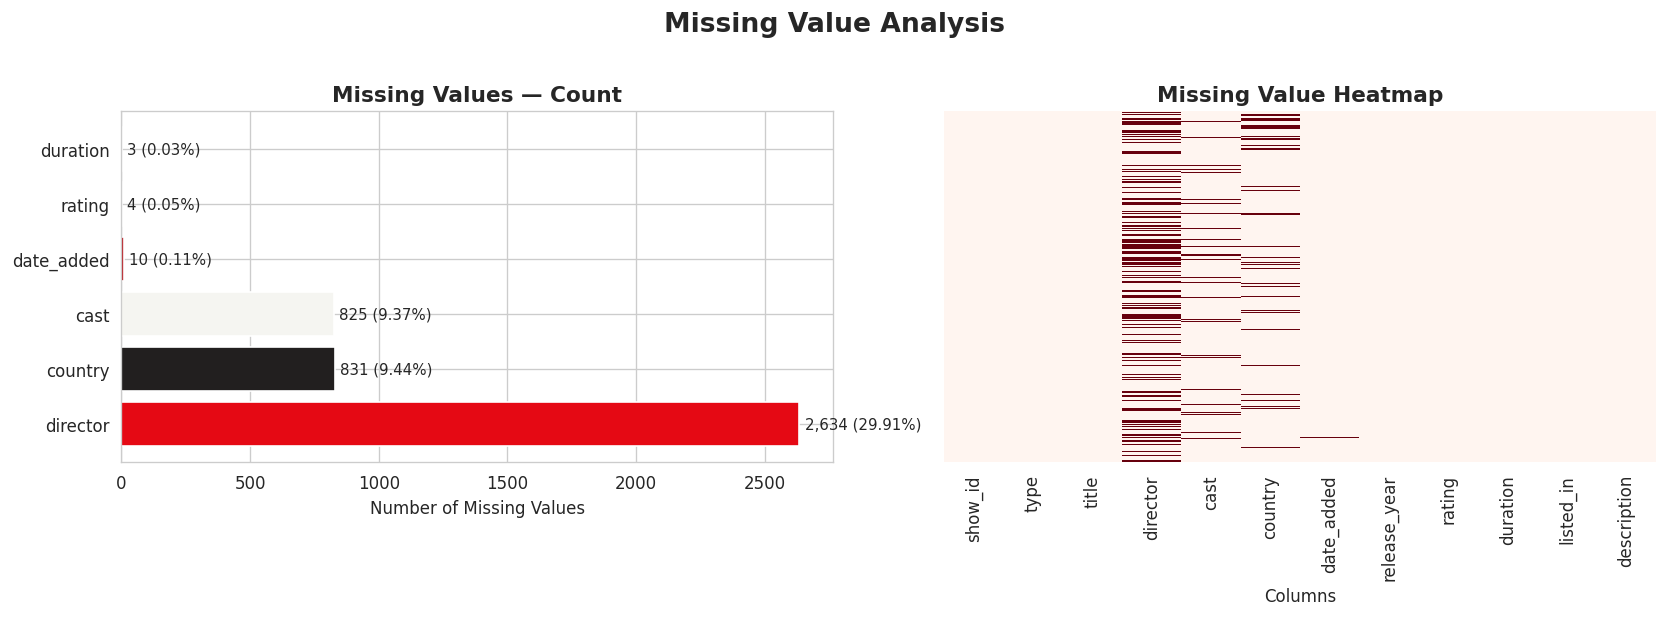


💡 Business Insight: 'director' has the highest missing rate (29.9%). This is
   expected — TV Shows often lack a single director. We'll fill nulls with 'Unknown'.


In [9]:
# ── Visualize Missing Values ─────────────────────────────────────
missing_cols = missing_df[missing_df['Missing Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=16, fontweight='bold', y=1.02)

# Bar chart of missing counts
axes[0].barh(missing_cols.index, missing_cols['Missing Count'],
             color=PALETTE[:len(missing_cols)], edgecolor='white')
axes[0].set_title('Missing Values — Count', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Missing Values')
for i, (val, pct) in enumerate(zip(missing_cols['Missing Count'], missing_cols['Missing %'])):
    axes[0].text(val + 20, i, f'{val:,} ({pct}%)', va='center', fontsize=9)

# Heatmap of missing values
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=axes[1])
axes[1].set_title('Missing Value Heatmap', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n💡 Business Insight: 'director' has the highest missing rate (29.9%). This is")
print("   expected — TV Shows often lack a single director. We'll fill nulls with 'Unknown'.")


---
## 🧹 Section 5: Data Cleaning & Preprocessing

A data analyst spends ~60–80% of their time cleaning data. Here we handle missing values,  
fix data types, extract features, and prepare the dataset for analysis.


In [10]:
# ── Step 1: Handle Missing Values ────────────────────────────────
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('No Cast Info', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['date_added'].fillna('Unknown', inplace=True)

# Drop rows where 'duration' is missing (only 3 rows)
df.dropna(subset=['duration'], inplace=True)

print(f"✅ Missing values handled.")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")


✅ Missing values handled.
   Remaining missing values: 4304


In [11]:
# ── Step 2: Remove Duplicates ─────────────────────────────────────
dups = df.duplicated().sum()
print(f"🔁 Duplicate rows found: {dups}")
df.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed. Dataset now has {len(df):,} rows.")


🔁 Duplicate rows found: 0
✅ Duplicates removed. Dataset now has 8,804 rows.


In [12]:
# ── Step 3: Convert date_added to datetime ────────────────────────
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year and month added
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%b')

print("✅ Date features extracted:")
print(df[['date_added', 'year_added', 'month_added', 'month_name']].head(3))


✅ Date features extracted:
  date_added  year_added  month_added month_name
0 2021-09-25      2021.0          9.0        Sep
1 2021-09-24      2021.0          9.0        Sep
2 2021-09-24      2021.0          9.0        Sep


In [13]:
# ── Step 4: Extract duration numbers ─────────────────────────────
# Separate duration for movies (minutes) vs TV shows (seasons)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Separate DataFrames for movies and shows
movies = df[df['type'] == 'Movie'].copy()
shows  = df[df['type'] == 'TV Show'].copy()

print(f"🎬 Movies  : {len(movies):,} titles")
print(f"📺 TV Shows: {len(shows):,} titles")
print(f"\n✅ Data Cleaning Complete! Dataset ready for analysis.")


🎬 Movies  : 6,128 titles
📺 TV Shows: 2,676 titles

✅ Data Cleaning Complete! Dataset ready for analysis.


In [14]:
# ── Final Cleaned Dataset Preview ────────────────────────────────
print("🧼 Cleaned Dataset — First 5 rows:")
df[['title','type','country','rating','release_year','year_added','duration_int']].head()


🧼 Cleaned Dataset — First 5 rows:


,title,type,country,rating,release_year,year_added,duration_int
0,Dick Johnson Is Dead,Movie,United States,PG-13,2020,2021.0,90.0
1,Blood & Water,TV Show,South Africa,TV-MA,2021,2021.0,2.0
2,Ganglands,TV Show,NaN,TV-MA,2021,2021.0,1.0
3,Jailbirds New Orleans,TV Show,NaN,TV-MA,2021,2021.0,1.0
4,Kota Factory,TV Show,India,TV-MA,2021,2021.0,2.0


---
## 📊 Section 6: Exploratory Data Analysis & Visualizations

Now the exciting part! Let's visualize Netflix's content library from multiple angles  
and derive meaningful business insights from each chart.

---


### 6.1 🎬 Movies vs TV Shows — Pie Chart

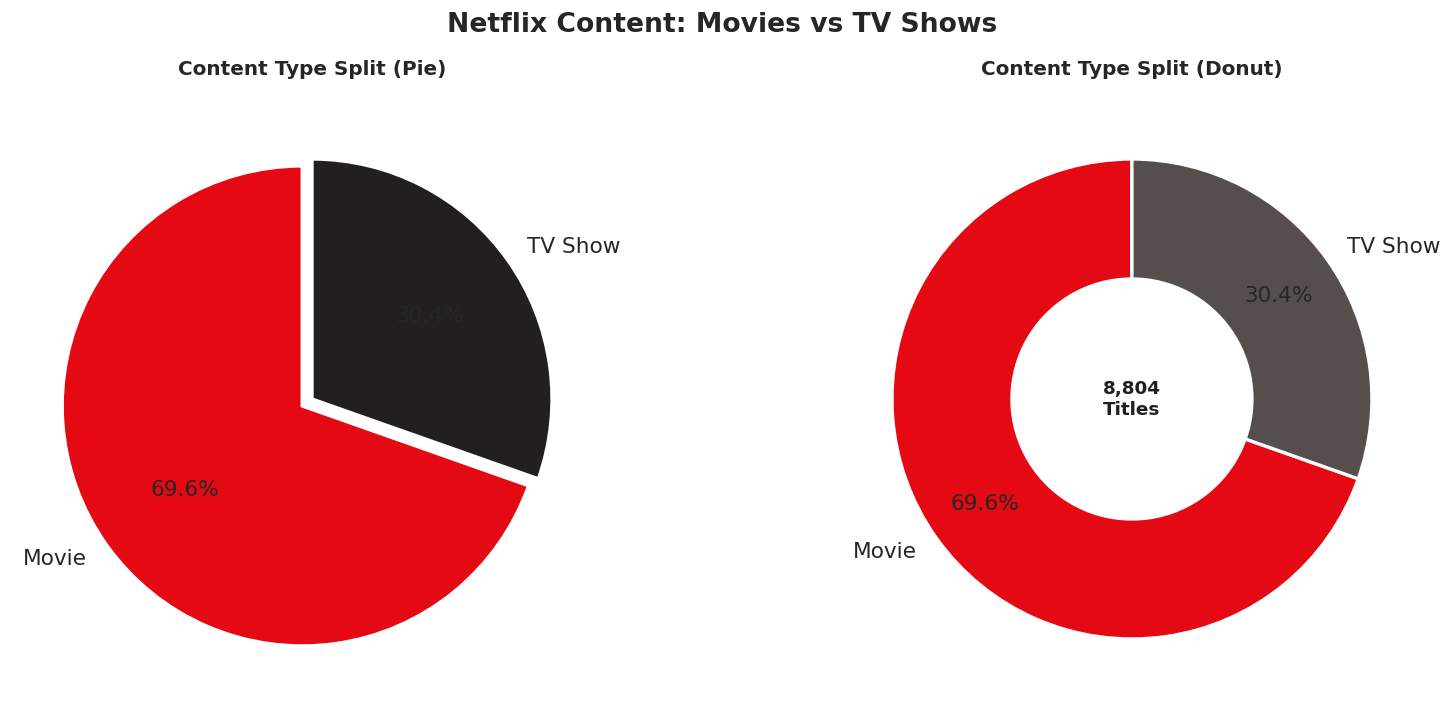


💡 Business Insight:
   • Netflix's library is dominated by Movies (6,128 = 69.6%).
   • TV Shows (2,676 = 30.4%) are growing as binge-watching culture rises.
   • This 70:30 ratio suggests Netflix invests more in film licensing & production.


In [15]:
# ── Content Type Distribution ─────────────────────────────────────
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Netflix Content: Movies vs TV Shows', fontsize=16, fontweight='bold')

# Pie chart
wedge_props = dict(linewidth=2, edgecolor='white')
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914', '#221F1F'], startangle=90,
            wedgeprops=wedge_props, textprops={'fontsize': 13},
            explode=(0.05, 0))
axes[0].set_title('Content Type Split (Pie)', fontweight='bold', pad=15)

# Donut chart
wedge_props2 = dict(linewidth=2, edgecolor='white', width=0.5)
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914', '#564D4D'], startangle=90,
            wedgeprops=wedge_props2, textprops={'fontsize': 13},
            pctdistance=0.75)
axes[1].set_title('Content Type Split (Donut)', fontweight='bold', pad=15)
centre = plt.Circle((0,0), 0.35, fc='white')
axes[1].add_patch(centre)
axes[1].text(0, 0, f'{len(df):,}\nTitles', ha='center', va='center',
             fontsize=11, fontweight='bold', color='#221F1F')

plt.tight_layout()
plt.savefig('content_type_split.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n💡 Business Insight:")
print(f"   • Netflix's library is dominated by Movies ({type_counts['Movie']:,} = {type_counts['Movie']/len(df)*100:.1f}%).")
print(f"   • TV Shows ({type_counts['TV Show']:,} = {type_counts['TV Show']/len(df)*100:.1f}%) are growing as binge-watching culture rises.")
print(f"   • This 70:30 ratio suggests Netflix invests more in film licensing & production.")


### 6.2  Top 15 Countries by Content Volume — Horizontal Bar Chart

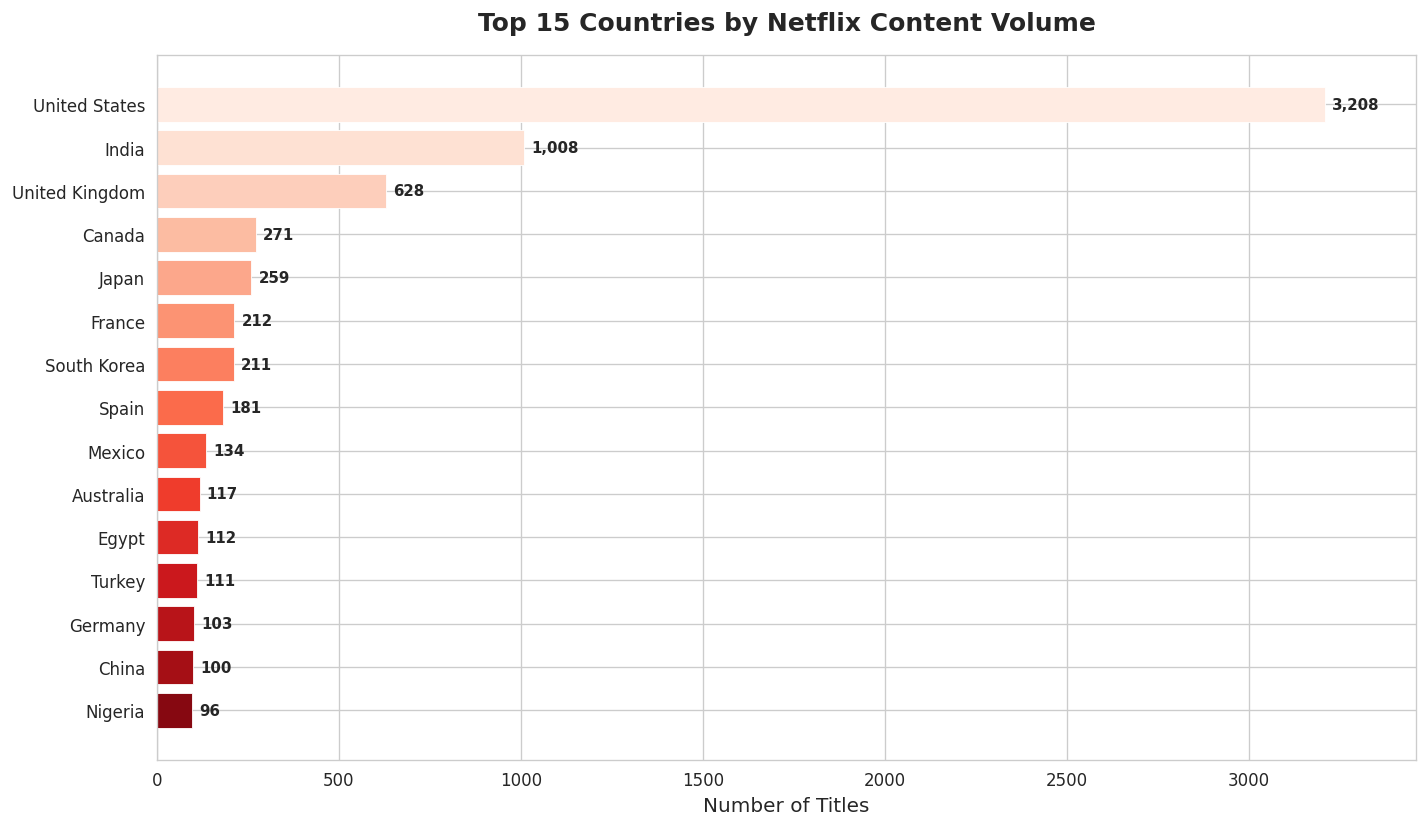


💡 Business Insight:
   • The United States leads by a massive margin — Netflix's home market dominates.
   • India is #2, reflecting Netflix's aggressive expansion in South Asian markets.
   • UK, Japan, and South Korea round out the top 5, highlighting global diversification.
   • South Korea's Hallyu wave has made K-content a strategic Netflix priority.


In [16]:
# ── Country-wise Content Distribution ────────────────────────────
# Some entries have multiple countries — take the first (primary)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
country_counts = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=sns.color_palette("Reds_r", 15), edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, country_counts.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 15 Countries by Netflix Content Volume', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, country_counts.max() + 250)
plt.tight_layout()
plt.savefig('country_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • The United States leads by a massive margin — Netflix's home market dominates.")
print("   • India is #2, reflecting Netflix's aggressive expansion in South Asian markets.")
print("   • UK, Japan, and South Korea round out the top 5, highlighting global diversification.")
print("   • South Korea's Hallyu wave has made K-content a strategic Netflix priority.")


### 6.3  Content Ratings Distribution — Count Plot

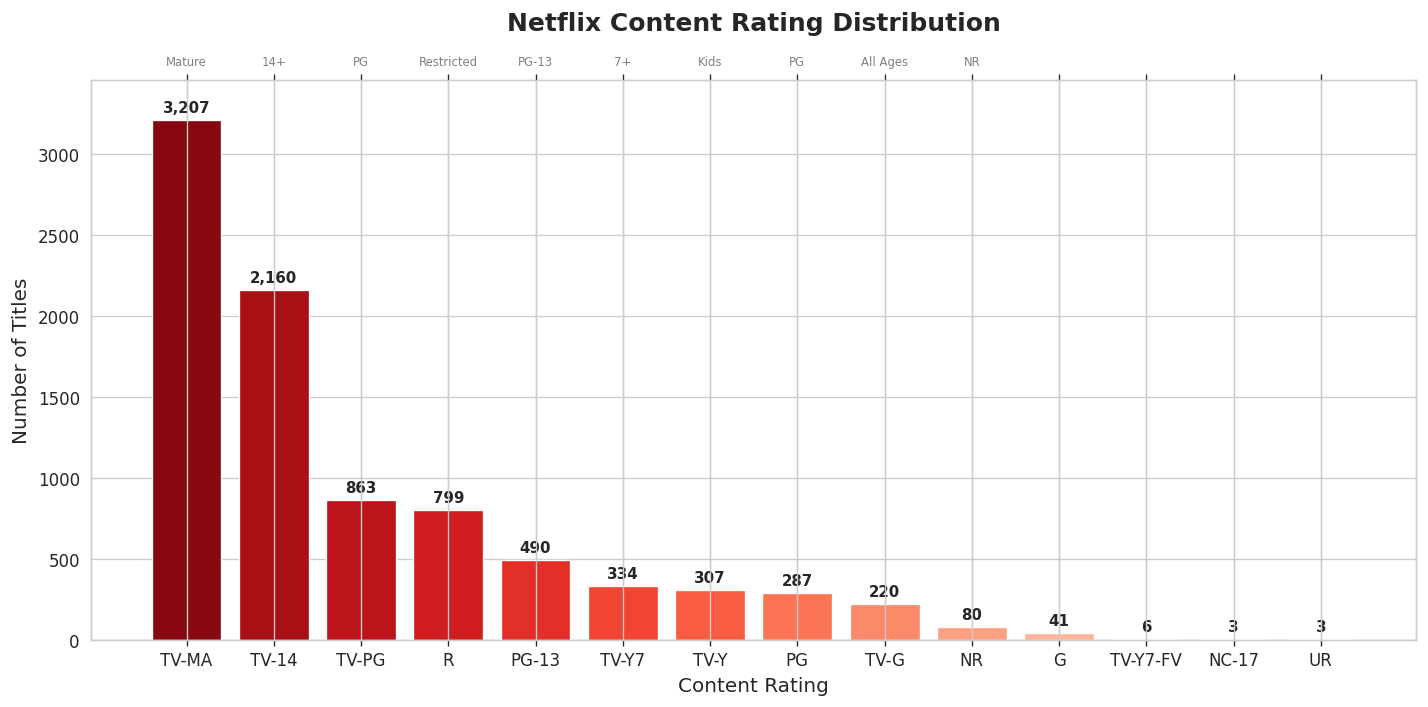


💡 Business Insight:
   • TV-MA (Mature Audiences) is #1 — Netflix leans into adult content to differentiate.
   • TV-14 and R-rated content together cover ~50% — confirming a teen/adult focus.
   • Family-friendly (TV-G, TV-Y, PG) content is a smaller but important segment.
   • This signals Netflix targets 18–35 demographic primarily.


In [17]:
# ── Ratings Analysis ──────────────────────────────────────────────
rating_counts = df[df['rating'] != 'Not Rated']['rating'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=sns.color_palette("Reds_r", len(rating_counts)),
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Netflix Content Rating Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Content Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.set_ylim(0, rating_counts.max() + 250)

# Add rating descriptions
rating_desc = {'TV-MA':'Mature','TV-14':'14+','TV-PG':'PG','R':'Restricted','PG-13':'PG-13','TV-Y7':'7+','TV-Y':'Kids','PG':'PG','TV-G':'All Ages','NR':'NR'}
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(range(len(rating_counts)))
ax2.set_xticklabels([rating_desc.get(r,'') for r in rating_counts.index],
                    fontsize=7, color='gray')
plt.tight_layout()
plt.savefig('ratings_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • TV-MA (Mature Audiences) is #1 — Netflix leans into adult content to differentiate.")
print("   • TV-14 and R-rated content together cover ~50% — confirming a teen/adult focus.")
print("   • Family-friendly (TV-G, TV-Y, PG) content is a smaller but important segment.")
print("   • This signals Netflix targets 18–35 demographic primarily.")


### 6.4 🎭 Top 10 Genres — Bar Chart

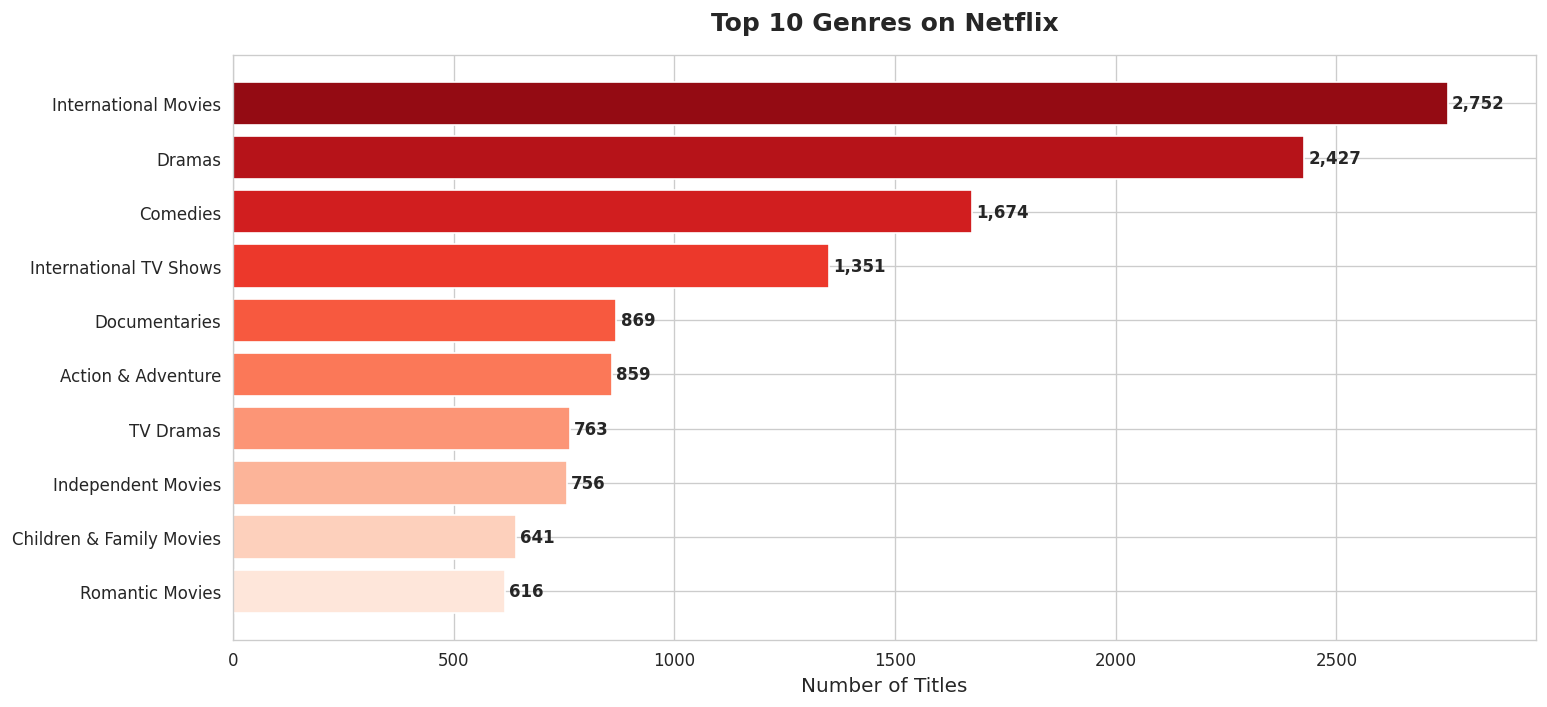


💡 Business Insight:
   • International Movies & Dramas dominate — Netflix's global expansion strategy is working.
   • Comedies and Documentaries are consistently strong — broad appeal categories.
   • Stand-Up Comedy's presence reflects Netflix's original content investment.
   • Action & Adventure and Thrillers attract male-skewing demographics.


In [18]:
# ── Genre Analysis ───────────────────────────────────────────────
# 'listed_in' contains comma-separated genres — explode them
genre_series = df['listed_in'].str.split(',').explode().str.strip()
genre_counts = genre_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Reds_r", len(genre_counts))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Genres on Netflix', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_xlim(0, genre_counts.max() + 200)
plt.tight_layout()
plt.savefig('top_genres.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • International Movies & Dramas dominate — Netflix's global expansion strategy is working.")
print("   • Comedies and Documentaries are consistently strong — broad appeal categories.")
print("   • Stand-Up Comedy's presence reflects Netflix's original content investment.")
print("   • Action & Adventure and Thrillers attract male-skewing demographics.")


### 6.5 📅 Content Added to Netflix by Year — Line Chart

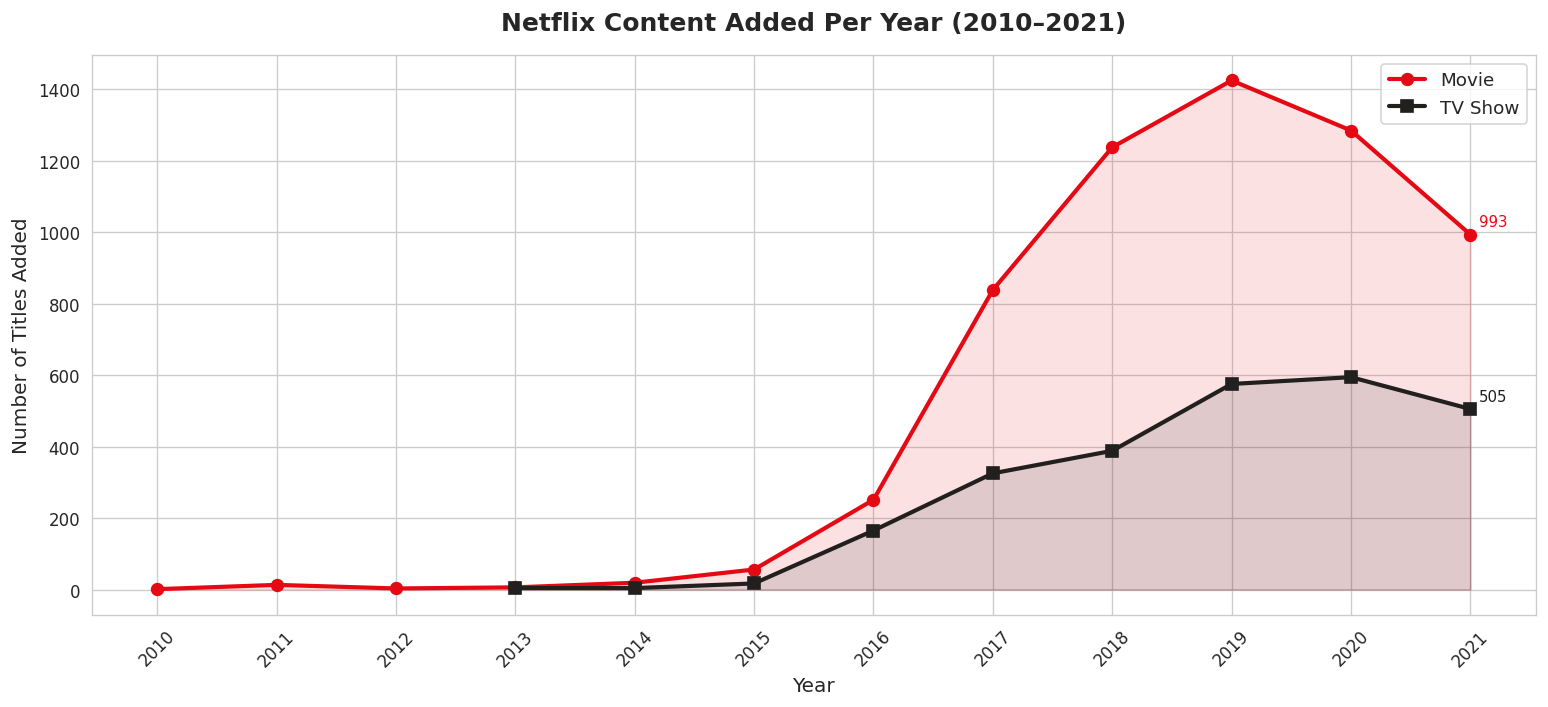


💡 Business Insight:
   • Netflix's content library grew exponentially from 2014 onwards.
   • Peak content addition was in 2019–2020 as Netflix ramped up Originals strategy.
   • 2020 shows a slight dip in Movies (COVID-19 production slowdowns).
   • TV Show growth has been steady, reflecting subscriber demand for serialized content.


In [19]:
# ── Year-wise Content Growth ──────────────────────────────────────
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
yearly = yearly[yearly['year_added'].between(2010, 2021)]

fig, ax = plt.subplots(figsize=(13, 6))
for content_type, color, marker in zip(['Movie', 'TV Show'],
                                        ['#E50914', '#221F1F'],
                                        ['o', 's']):
    data = yearly[yearly['type'] == content_type]
    ax.plot(data['year_added'], data['count'], color=color, linewidth=2.5,
            marker=marker, markersize=7, label=content_type)
    # Fill area under line
    ax.fill_between(data['year_added'], data['count'], alpha=0.12, color=color)
    # Annotate last point
    last = data.iloc[-1]
    ax.annotate(f"{int(last['count'])}", xy=(last['year_added'], last['count']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, color=color)

ax.set_title('Netflix Content Added Per Year (2010–2021)', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.legend(fontsize=11, framealpha=0.8)
ax.set_xticks(range(2010, 2022))
ax.xaxis.set_tick_params(rotation=45)
plt.tight_layout()
plt.savefig('yearly_growth.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • Netflix's content library grew exponentially from 2014 onwards.")
print("   • Peak content addition was in 2019–2020 as Netflix ramped up Originals strategy.")
print("   • 2020 shows a slight dip in Movies (COVID-19 production slowdowns).")
print("   • TV Show growth has been steady, reflecting subscriber demand for serialized content.")


### 6.6 📆 Content Added by Month — Bar Chart (Seasonality)

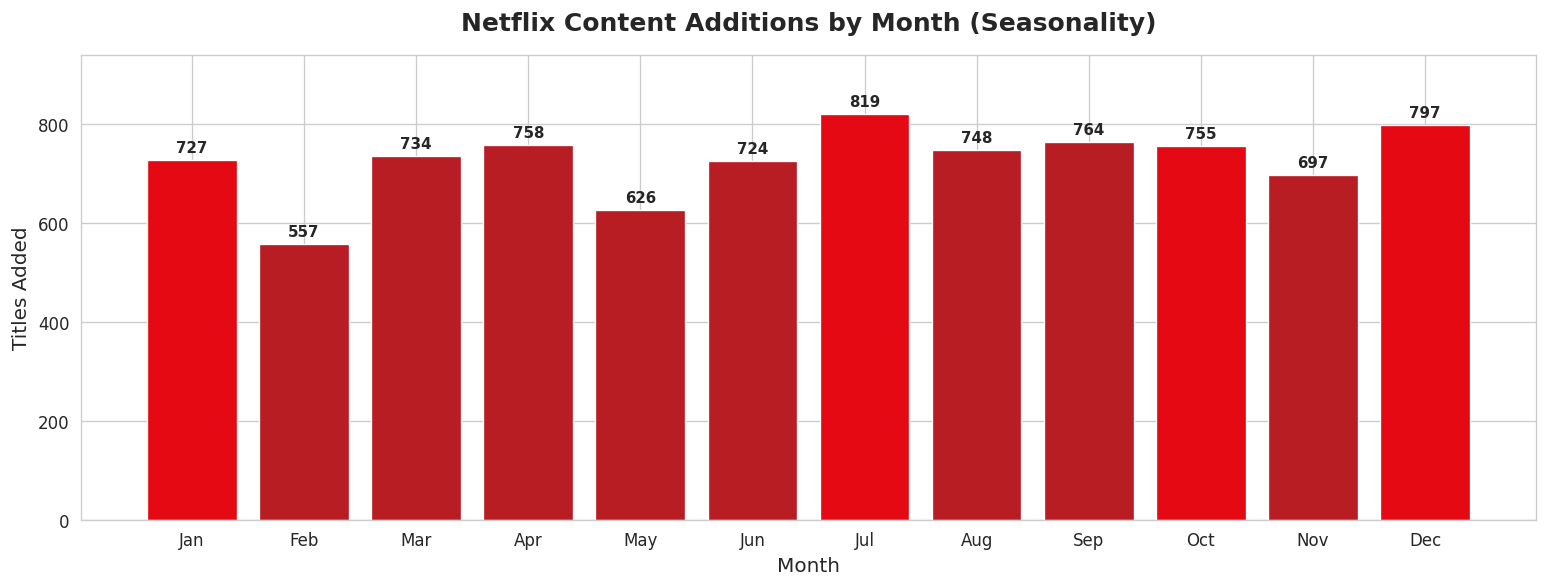


💡 Business Insight:
   • January sees a surge — New Year content drops attract subscribers.
   • October/November spike aligns with holiday season programming strategy.
   • July is strong — summer binge-watching drives mid-year content releases.
   • February is consistently low — fewest new titles added each year.


In [20]:
# ── Monthly Content Addition Patterns ────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['month_name'].value_counts().reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#E50914' if m in ['Jan','Jul','Oct','Dec'] else '#B81D24'
              for m in month_order]
bars = ax.bar(month_order, month_counts.values, color=bar_colors,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, month_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Netflix Content Additions by Month (Seasonality)', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Titles Added', fontsize=12)
ax.set_ylim(0, month_counts.max() + 120)
plt.tight_layout()
plt.savefig('monthly_seasonality.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • January sees a surge — New Year content drops attract subscribers.")
print("   • October/November spike aligns with holiday season programming strategy.")
print("   • July is strong — summer binge-watching drives mid-year content releases.")
print("   • February is consistently low — fewest new titles added each year.")


### 6.7 🎬 Most Prolific Directors on Netflix — Bar Chart

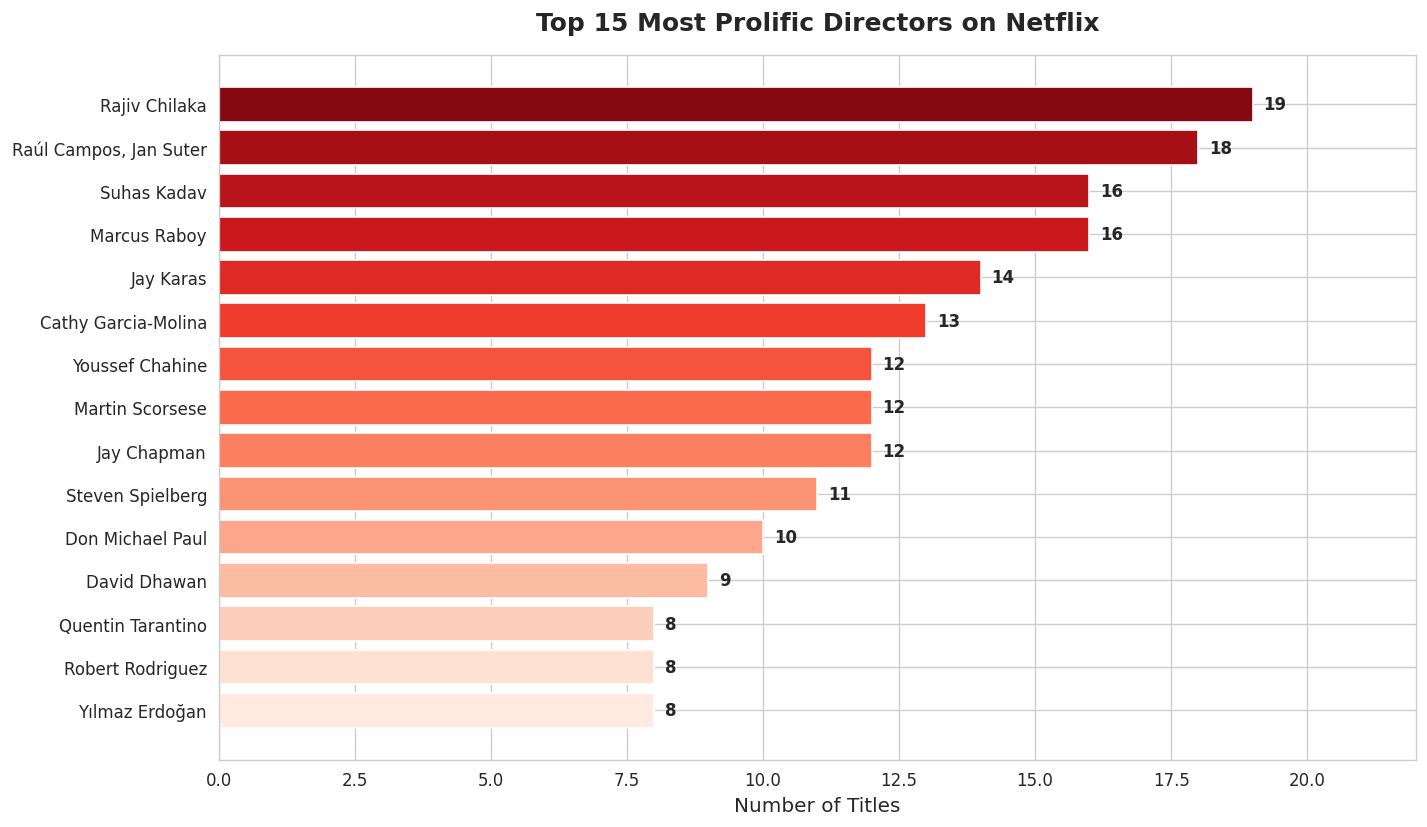


💡 Business Insight:
   • Rajiv Chilaka leads with 19 titles — creator of 'Chhota Bheem' (India market focus).
   • Raúl Campos & Jan Suter (18) — Spanish-language content for Latin America.
   • Martin Scorsese and Steven Spielberg confirm Netflix licenses Hollywood classics.
   • Most top directors specialize in family/children content — a key growth segment.


In [21]:
# ── Top 15 Directors (excluding Unknown) ──────────────────────────
top_directors = (df[df['director'] != 'Unknown']['director']
                 .value_counts()
                 .head(15))

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("Reds_r", len(top_directors))
bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 15 Most Prolific Directors on Netflix', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_xlim(0, top_directors.max() + 3)
plt.tight_layout()
plt.savefig('top_directors.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • Rajiv Chilaka leads with 19 titles — creator of 'Chhota Bheem' (India market focus).")
print("   • Raúl Campos & Jan Suter (18) — Spanish-language content for Latin America.")
print("   • Martin Scorsese and Steven Spielberg confirm Netflix licenses Hollywood classics.")
print("   • Most top directors specialize in family/children content — a key growth segment.")


### 6.8 ⏱️ Movie Duration Distribution — Histogram & Box Plot

📊 Movie Duration Statistics:
   Min    : 3 min
   Max    : 312 min
   Mean   : 99.6 min (1.7 hrs)
   Median : 98 min
   Std Dev: 28.3 min


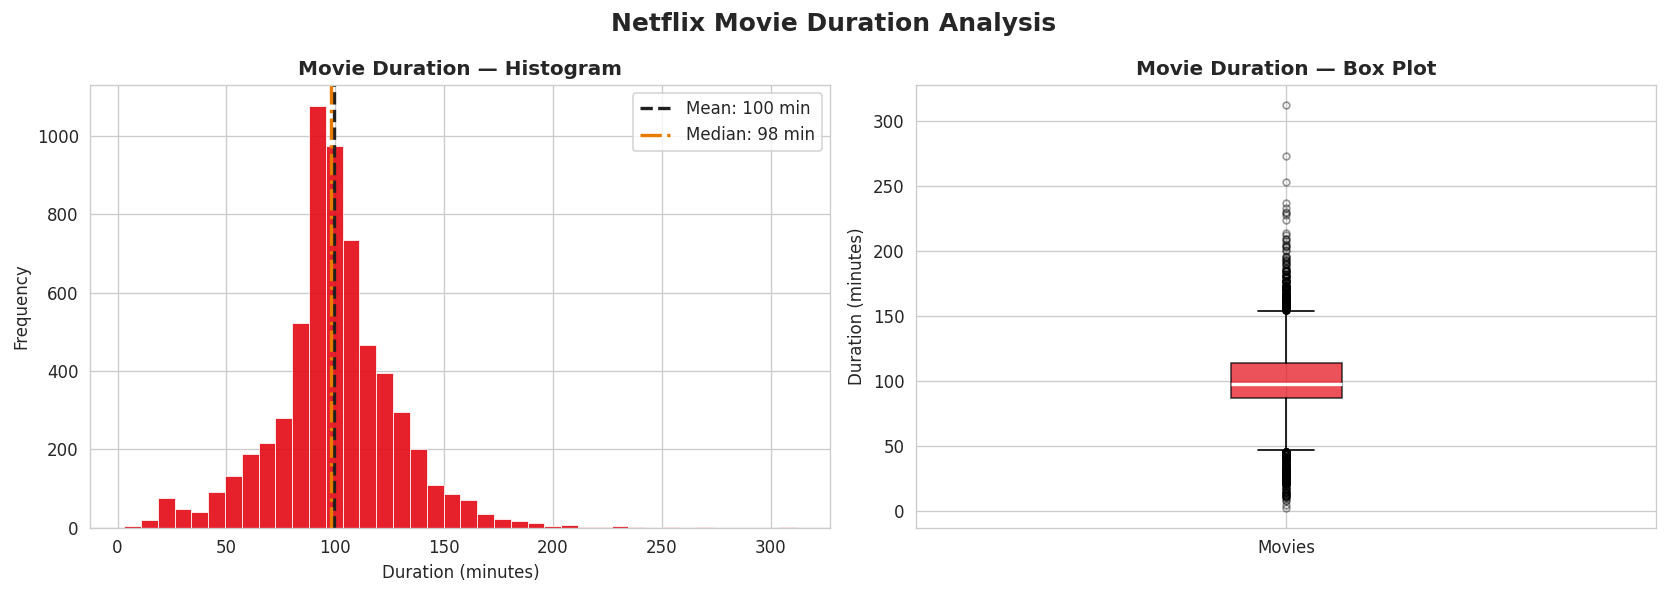


💡 Business Insight:
   • Average Netflix movie runs ~99 minutes — standard theatrical length.
   • Most movies cluster between 80–120 mins (the sweet spot for streaming.
   • Outliers > 150 mins are typically acclaimed films or documentaries.
   • Very short films (<40 min) are often comedy specials or shorts.


In [22]:
# ── Movie Duration Analysis ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Netflix Movie Duration Analysis', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(movies['duration_int'].dropna(), bins=40, color='#E50914',
             edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0].axvline(movies['duration_int'].mean(), color='#221F1F',
                linestyle='--', linewidth=2, label=f"Mean: {movies['duration_int'].mean():.0f} min")
axes[0].axvline(movies['duration_int'].median(), color='#E87C03',
                linestyle='-.', linewidth=2, label=f"Median: {movies['duration_int'].median():.0f} min")
axes[0].set_title('Movie Duration — Histogram', fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box Plot
bp = axes[1].boxplot(movies['duration_int'].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#E50914', alpha=0.7),
                      medianprops=dict(color='white', linewidth=2),
                      flierprops=dict(marker='o', color='#221F1F', markersize=4, alpha=0.4))
axes[1].set_title('Movie Duration — Box Plot', fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_xlabel('')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Movies'])

stats = movies['duration_int'].describe()
print("📊 Movie Duration Statistics:")
print(f"   Min    : {stats['min']:.0f} min")
print(f"   Max    : {stats['max']:.0f} min")
print(f"   Mean   : {stats['mean']:.1f} min ({stats['mean']/60:.1f} hrs)")
print(f"   Median : {stats['50%']:.0f} min")
print(f"   Std Dev: {stats['std']:.1f} min")

plt.tight_layout()
plt.savefig('movie_duration.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • Average Netflix movie runs ~99 minutes — standard theatrical length.")
print("   • Most movies cluster between 80–120 mins (the sweet spot for streaming.")
print("   • Outliers > 150 mins are typically acclaimed films or documentaries.")
print("   • Very short films (<40 min) are often comedy specials or shorts.")


### 6.9 📺 TV Show Seasons Distribution — Count Plot

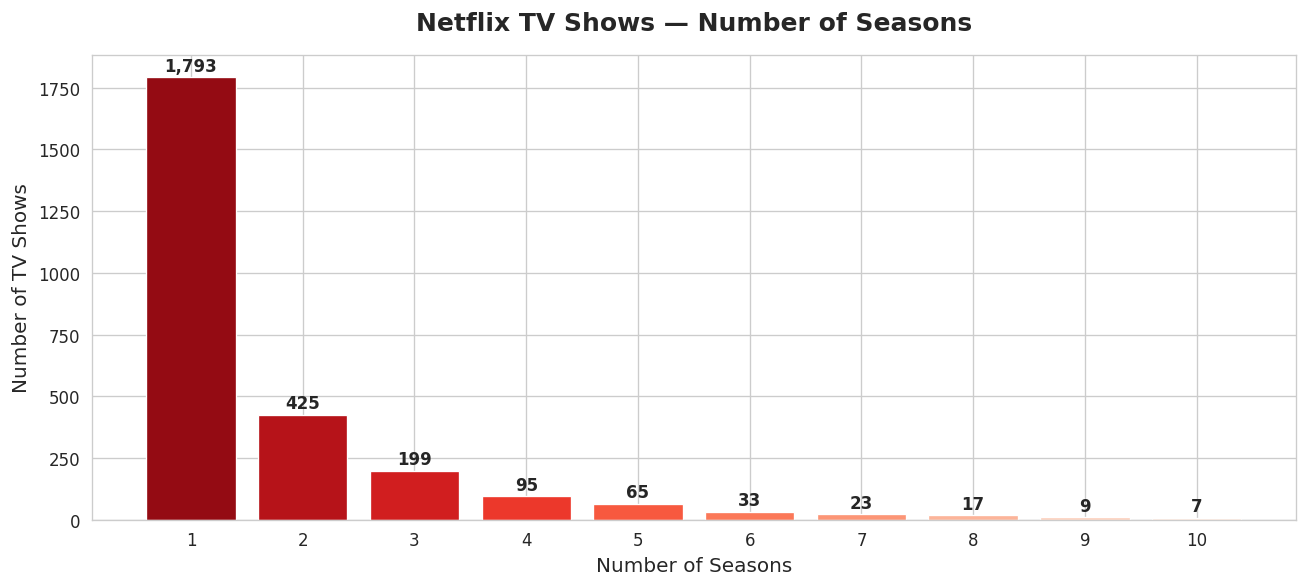


💡 Business Insight:
   • 1,793 TV Shows (67.0%) have exactly 1 season.
   • Most shows don't get renewed — Netflix cancels underperforming titles quickly.
   • Multi-season shows (5+) are fan favorites with established audiences.
   • This pattern reflects Netflix's 'test and cancel' content strategy.


In [23]:
# ── TV Show Season Distribution ───────────────────────────────────
season_counts = shows['duration_int'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(season_counts.index.astype(int), season_counts.values,
              color=sns.color_palette("Reds_r", len(season_counts)),
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, season_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Netflix TV Shows — Number of Seasons', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Number of Seasons', fontsize=12)
ax.set_ylabel('Number of TV Shows', fontsize=12)
ax.set_xticks(season_counts.index.astype(int))
plt.tight_layout()
plt.savefig('tv_seasons.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print(f"   • {season_counts[1]:,} TV Shows ({season_counts[1]/len(shows)*100:.1f}%) have exactly 1 season.")
print("   • Most shows don't get renewed — Netflix cancels underperforming titles quickly.")
print("   • Multi-season shows (5+) are fan favorites with established audiences.")
print("   • This pattern reflects Netflix's 'test and cancel' content strategy.")


### 6.10 🔥 Correlation Heatmap — Numerical Features

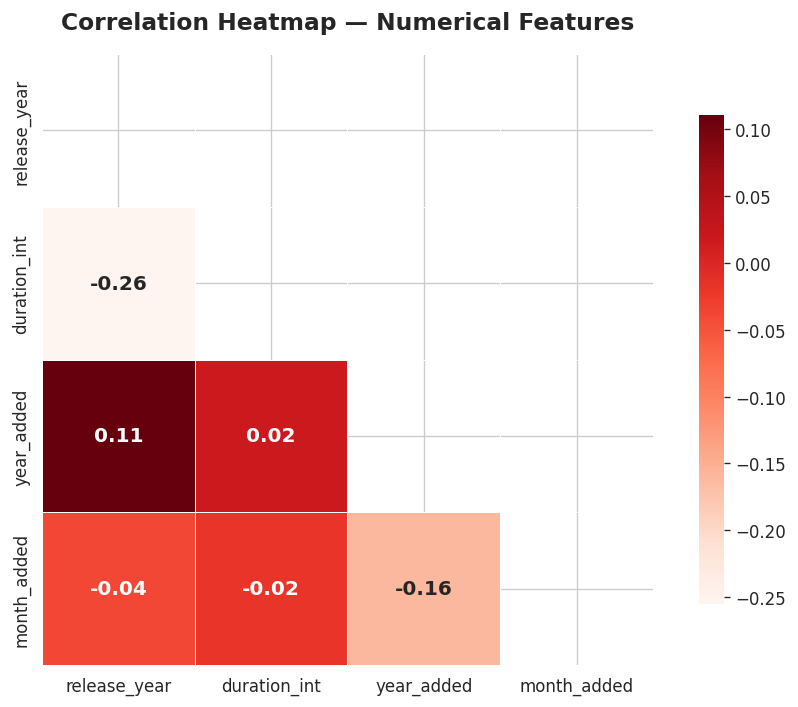


💡 Business Insight:
   • 'release_year' and 'year_added' show moderate correlation — Netflix adds recent content.
   • 'duration_int' has very low correlation with year — movie lengths aren't changing.
   • 'month_added' is essentially independent of other features (seasonal but not correlated).


In [24]:
# ── Correlation Heatmap ───────────────────────────────────────────
num_df = df[['release_year', 'duration_int', 'year_added', 'month_added']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 12, 'fontweight': 'bold'},
            square=True, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • 'release_year' and 'year_added' show moderate correlation — Netflix adds recent content.")
print("   • 'duration_int' has very low correlation with year — movie lengths aren't changing.")
print("   • 'month_added' is essentially independent of other features (seasonal but not correlated).")


### 6.11 Movies vs TV Shows — Top 10 Countries (Stacked Bar)

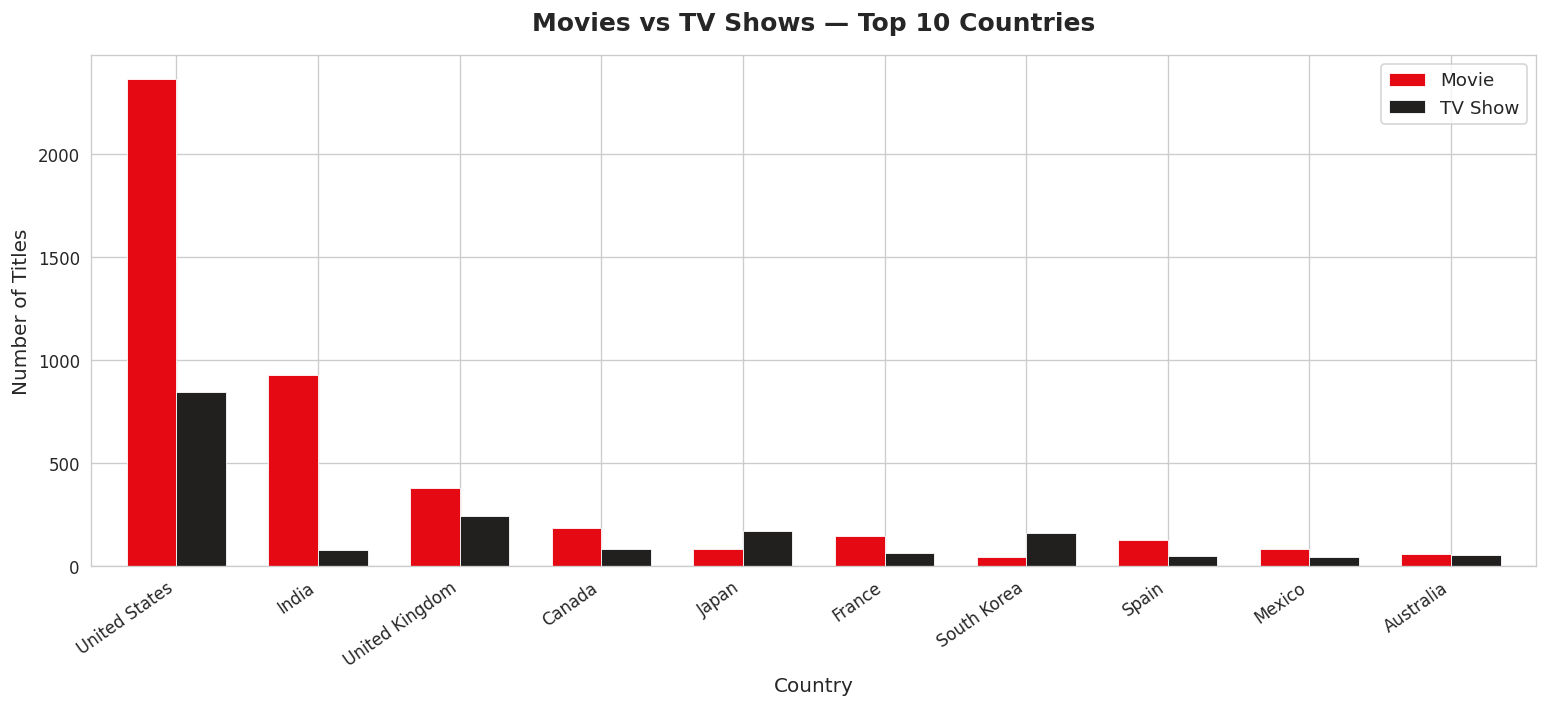


💡 Business Insight:
   • US, India, UK — primarily movie-heavy libraries.
   • South Korea and Japan have strong TV Show proportions (anime, K-dramas).
   • This shows how content strategy varies by market — US = films, Asia = series.


In [25]:
# ── Country × Content Type Breakdown ──────────────────────────────
top10_countries = (df[df['primary_country'] != 'Unknown']['primary_country']
                   .value_counts().head(10).index.tolist())

country_type = (df[df['primary_country'].isin(top10_countries)]
                .groupby(['primary_country', 'type']).size()
                .unstack(fill_value=0)
                .loc[top10_countries])

fig, ax = plt.subplots(figsize=(13, 6))
country_type.plot(kind='bar', ax=ax, color=['#E50914', '#221F1F'],
                  edgecolor='white', linewidth=0.5, width=0.7)

ax.set_title('Movies vs TV Shows — Top 10 Countries', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(['Movie', 'TV Show'], fontsize=11, framealpha=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('country_type.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • US, India, UK — primarily movie-heavy libraries.")
print("   • South Korea and Japan have strong TV Show proportions (anime, K-dramas).")
print("   • This shows how content strategy varies by market — US = films, Asia = series.")


### 6.12 📈 Content Release Year Distribution — Histogram

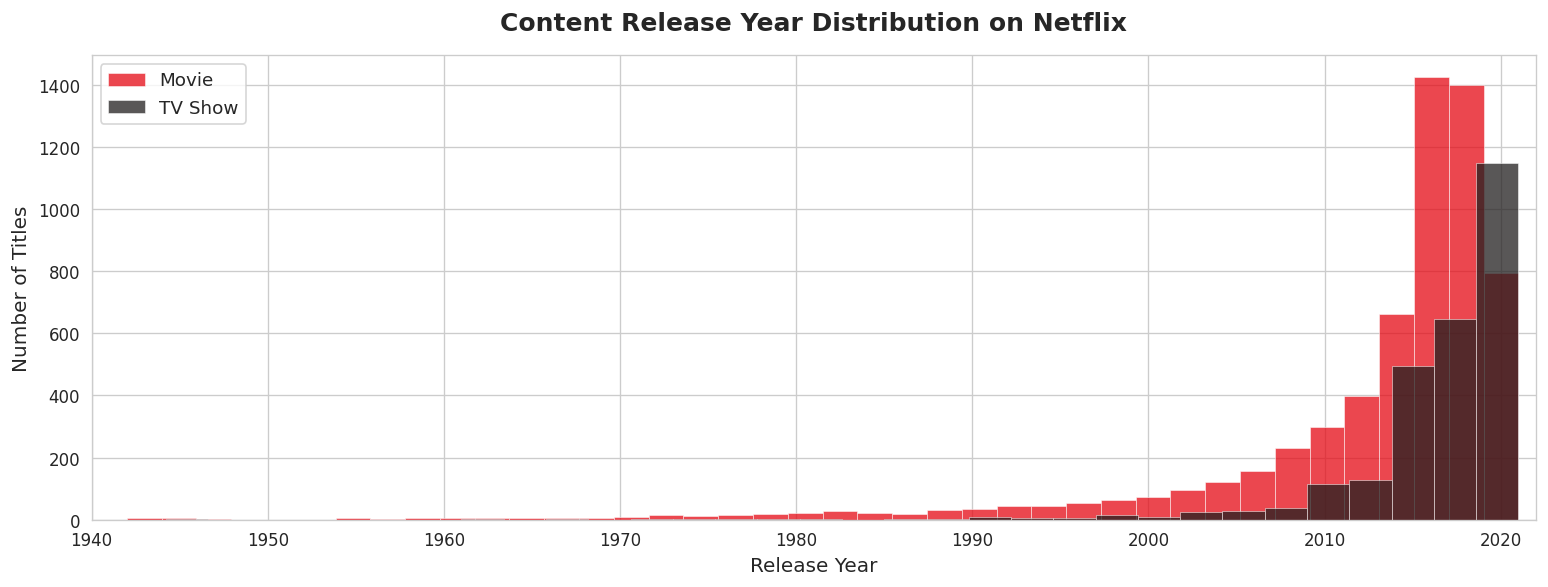


💡 Business Insight:
   • The overwhelming majority of Netflix content was released post-2010.
   • Netflix has been digitizing classic films but focuses on contemporary content.
   • The 2015–2021 spike reflects Netflix Originals production boom.
   • Pre-2000 content exists but is a niche library for classic film enthusiasts.


In [26]:
# ── Release Year Histogram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for content_type, color in zip(['Movie', 'TV Show'], ['#E50914', '#221F1F']):
    data = df[df['type'] == content_type]['release_year']
    ax.hist(data, bins=40, alpha=0.75, label=content_type, color=color,
            edgecolor='white', linewidth=0.4)

ax.set_title('Content Release Year Distribution on Netflix', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(1940, 2022)
plt.tight_layout()
plt.savefig('release_year_hist.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • The overwhelming majority of Netflix content was released post-2010.")
print("   • Netflix has been digitizing classic films but focuses on contemporary content.")
print("   • The 2015–2021 spike reflects Netflix Originals production boom.")
print("   • Pre-2000 content exists but is a niche library for classic film enthusiasts.")


### 6.13 📊 Rating Distribution by Content Type — Grouped Bar

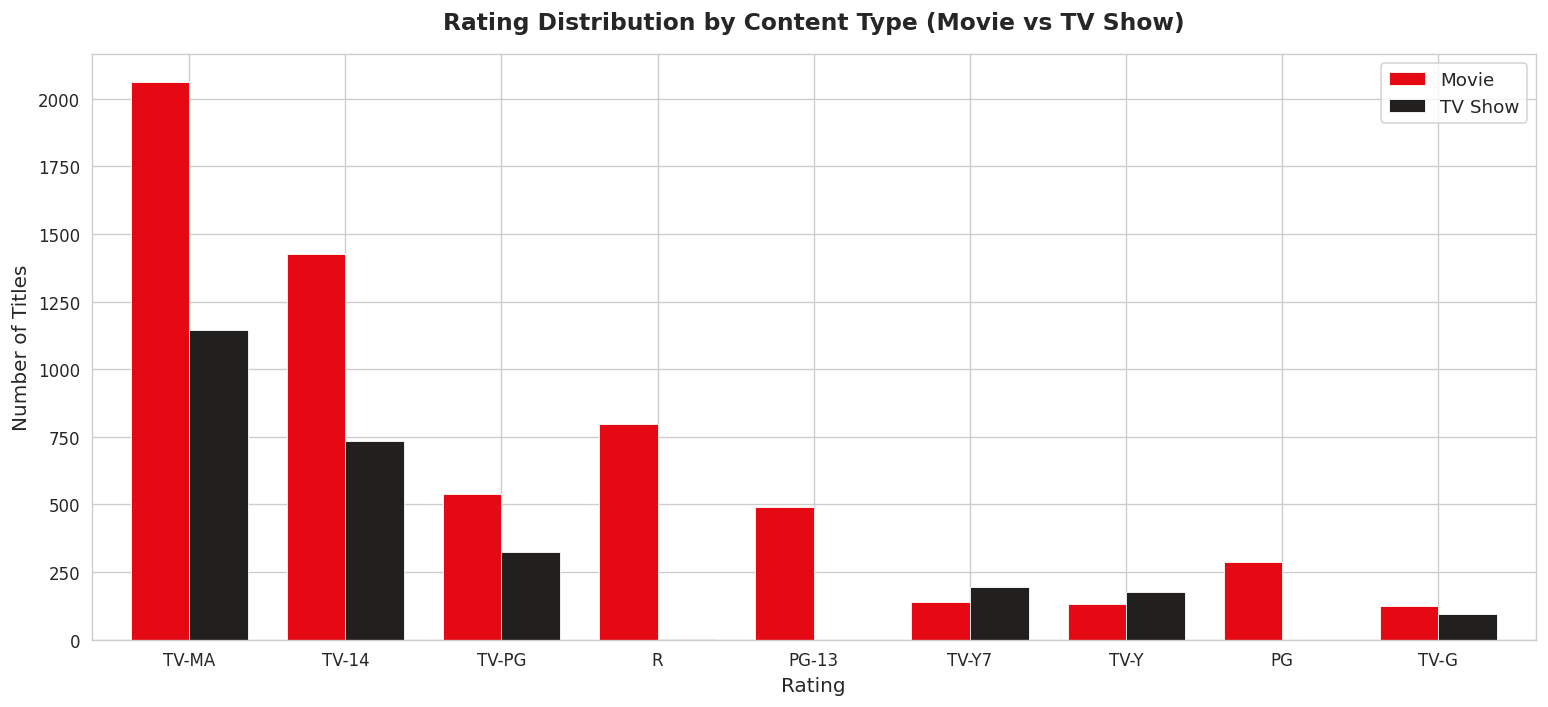


💡 Business Insight:
   • TV-MA is overwhelmingly TV Shows — adult drama is Netflix's streaming identity.
   • R-rated content is almost exclusively Movies — expected for cinema categorization.
   • PG/PG-13 movies outnumber TV Shows in family-friendly ratings.
   • TV-Y and TV-G skew heavily toward TV Shows — children's animation preference.


In [27]:
# ── Ratings by Type ───────────────────────────────────────────────
top_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G']
rating_type = (df[df['rating'].isin(top_ratings)]
               .groupby(['rating', 'type']).size()
               .unstack(fill_value=0)
               .reindex(top_ratings))

fig, ax = plt.subplots(figsize=(13, 6))
rating_type.plot(kind='bar', ax=ax, color=['#E50914', '#221F1F'],
                 edgecolor='white', linewidth=0.5, width=0.75)
ax.set_title('Rating Distribution by Content Type (Movie vs TV Show)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(['Movie', 'TV Show'], fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('rating_by_type.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Business Insight:")
print("   • TV-MA is overwhelmingly TV Shows — adult drama is Netflix's streaming identity.")
print("   • R-rated content is almost exclusively Movies — expected for cinema categorization.")
print("   • PG/PG-13 movies outnumber TV Shows in family-friendly ratings.")
print("   • TV-Y and TV-G skew heavily toward TV Shows — children's animation preference.")


### 6.14 🥧 Top 8 Genres — Donut Chart

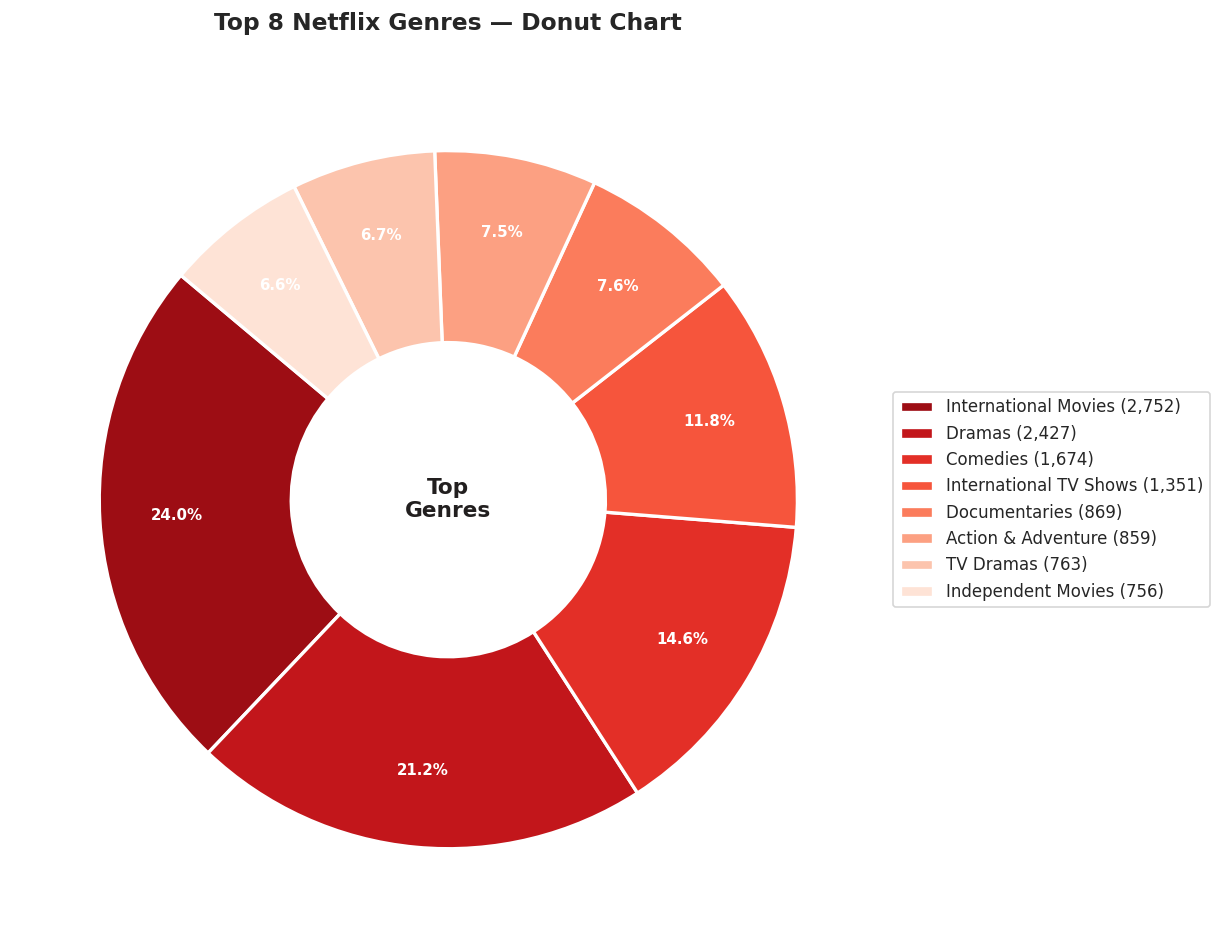

In [28]:
# ── Genre Donut Chart ─────────────────────────────────────────────
top_genres = genre_series.value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    top_genres.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '',
    colors=sns.color_palette("Reds_r", len(top_genres)) + ['#564D4D'],
    startangle=140,
    wedgeprops=dict(linewidth=2, edgecolor='white', width=0.55),
    pctdistance=0.78
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.legend(wedges, [f"{g} ({v:,})" for g, v in zip(top_genres.index, top_genres.values)],
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10, framealpha=0.8)
ax.text(0, 0, 'Top\nGenres', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#221F1F')
ax.set_title('Top 8 Netflix Genres — Donut Chart', fontsize=14,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('genre_donut.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 📋 Section 7: Key Statistics Summary


In [29]:
# ── Final Summary Statistics ─────────────────────────────────────
print("=" * 60)
print("         NETFLIX DATASET — KEY STATISTICS SUMMARY")
print("=" * 60)
print(f"  Total Titles          : {len(df):,}")
print(f"  Movies                : {len(movies):,} ({len(movies)/len(df)*100:.1f}%)")
print(f"  TV Shows              : {len(shows):,} ({len(shows)/len(df)*100:.1f}%)")
print(f"  Unique Countries      : {df['primary_country'].nunique():,}")
print(f"  Unique Directors      : {df[df['director']!='Unknown']['director'].nunique():,}")
print(f"  Unique Genres         : {genre_series.nunique():,}")
print(f"  Release Year Range    : {df['release_year'].min()} – {df['release_year'].max()}")
print(f"  Avg Movie Duration    : {movies['duration_int'].mean():.1f} minutes")
print(f"  Most Common Rating    : {df['rating'].value_counts().idxmax()}")
print(f"  Top Country           : {df['primary_country'].value_counts().idxmax()}")
print(f"  Top Genre             : {genre_series.value_counts().idxmax()}")
print(f"  Peak Year (additions) : {df['year_added'].value_counts().idxmax():.0f}")
print("=" * 60)


         NETFLIX DATASET — KEY STATISTICS SUMMARY
  Total Titles          : 8,804
  Movies                : 6,128 (69.6%)
  TV Shows              : 2,676 (30.4%)
  Unique Countries      : 86
  Unique Directors      : 4,527
  Unique Genres         : 42
  Release Year Range    : 1925 – 2021
  Avg Movie Duration    : 99.6 minutes
  Most Common Rating    : TV-MA
  Top Country           : United States
  Top Genre             : International Movies
  Peak Year (additions) : 2019


---
## 🏁 Section 8: Conclusion & Business Recommendations

---

### 📌 Key Findings

| # | Finding | Insight |
|---|---------|---------|
| 1 | **Movies dominate (69.6%)** | Netflix is primarily a film platform, but TV show share is growing |
| 2 | **USA + India = Top 2** | US is the core market; India is the biggest growth frontier |
| 3 | **TV-MA is #1 rating** | Netflix differentiates through mature, adult-oriented content |
| 4 | **1 Season = 67% of TV Shows** | Most shows are cancelled or designed as limited series |
| 5 | **Content exploded post-2015** | Netflix Originals strategy massively expanded the library |
| 6 | **Average movie: ~99 minutes** | Standard theatrical length dominates — familiar to subscribers |
| 7 | **Jan, Jul, Oct peak additions** | Clear seasonality tied to New Year, Summer, and Holiday cycles |
| 8 | **International Movies = Top Genre** | Global diversification is a core content pillar |

---

### 🚀 Business Recommendations

1. **Double down on India & South Korea** — These markets show massive engagement with local content and global crossover appeal (Squid Game, RRR).

2. **Expand family-friendly content** — TV-Y and PG-rated content is underrepresented vs mature content. Family plan subscribers are a major revenue stream.

3. **Invest in multi-season renewals** — Most TV shows end at 1 season. Shows with 3+ seasons drive subscriber retention and platform stickiness.

4. **Leverage seasonality** — Content drops in January and October perform well. Strategic release calendars should align with subscriber acquisition peaks.

5. **Genre diversification** — Crime, Thriller, and Documentary genres are growing fast. Original content in these genres can reduce licensing costs.

---

### 🛠️ Tools & Technologies Used

| Tool | Purpose |
|------|---------|
| **Python** | Primary analysis language |
| **Pandas** | Data loading, cleaning, manipulation |
| **NumPy** | Numerical operations, array handling |
| **Matplotlib** | Base chart creation and customization |
| **Seaborn** | Statistical visualizations, color palettes |
| **Jupyter Notebook** | Interactive development environment |

---

<div align="center">

### 👩‍💻 Project by Muskan Kumari
**B.Tech CSE | Government Engineering College Jamui | CGPA: 8.75**  
[LinkedIn](https://www.linkedin.com/in/muskan-kumari-b8ba012ba/) · [GitHub](https://github.com/Muskan-collab) · [HackerRank](https://www.hackerrank.com/profile/muskansingh05201)

*This notebook is part of my Data Analyst portfolio project — designed to demonstrate end-to-end EDA skills.*

</div>
